BLOCK 1 — Imports & Data Load

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from scipy import stats

# Global style
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a2e",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "text.color": "white",
    "axes.titlecolor": "white",
    "grid.color": "#2a2a4a",
    "figure.dpi": 130
})

df = pd.read_csv("datasets/examlevel.csv")

# Derived columns
df["Avg_Total"] = (df["Avg_Chem"] + df["Avg_Phy"] + df["Avg_Math"])
df["Cutoff_Total"] = df["Cutoff_Math"] + df["Cutoff_Phys"] + df["Cutoff_Chem"]
df["Topper_vs_Cutoff_Gap"] = df["Highest_Score"] - df["GE_Aggregate_Cutoff"]
df["Avg_pct"] = (df["Avg_Total"] / df["Total_Marks_Paper"]) * 100
df["Cutoff_pct"] = (df["GE_Aggregate_Cutoff"] / df["Total_Marks_Paper"]) * 100
df["Highest_pct"] = (df["Highest_Score"] / df["Total_Marks_Paper"]) * 100

print(df[["Year","Total_Marks_Paper","Avg_Total","Cutoff_pct","Highest_pct"]].to_string(index=False))

 Year  Total_Marks_Paper  Avg_Total  Cutoff_pct  Highest_pct
 2011                480      74.00   47.708333    91.666667
 2012                408      46.00   34.558824    94.362745
 2013                360      68.00   35.000000    92.222222
 2014                360      79.91   35.000000    92.777778
 2015                504      73.00   12.301587    93.055556
 2016                372      65.00   20.161290    86.021505
 2017                366     100.75   34.972678    92.622951
 2018                360      79.00   25.000000    93.611111
 2019                372      59.20   25.000000    93.010753
 2020                396      43.73   17.424242    88.888889
 2021                360      43.47   17.500000    96.666667
 2022                360      26.39   15.277778    87.222222
 2023                360      60.47   23.888889    94.722222
 2024                360      77.24   30.277778    98.611111
 2025                360      62.70   20.555556    92.222222


BLOCK 2 — Total Marks Pattern (Exam Structure Changes)

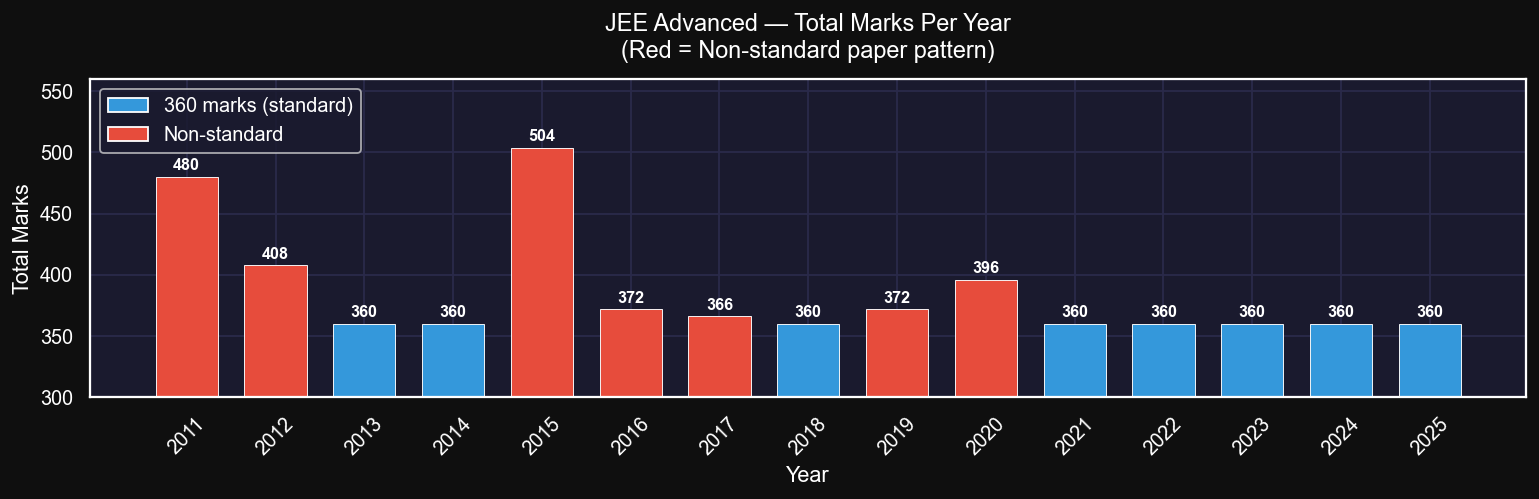

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))

colors = ["#e74c3c" if m != 360 else "#3498db" for m in df["Total_Marks_Paper"]]
bars = ax.bar(df["Year"], df["Total_Marks_Paper"], color=colors, edgecolor="white", linewidth=0.5, width=0.7)

for bar, val in zip(bars, df["Total_Marks_Paper"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha="center", va="bottom", fontsize=9, color="white", fontweight="bold")

ax.set_title("JEE Advanced — Total Marks Per Year\n(Red = Non-standard paper pattern)", fontsize=13, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Total Marks")
ax.set_xticks(df["Year"])
ax.set_xticklabels(df["Year"], rotation=45)
ax.set_ylim(300, 560)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='360 marks (standard)'),
                   Patch(facecolor='#e74c3c', label='Non-standard')]
ax.legend(handles=legend_elements, loc="upper left")

plt.tight_layout()
plt.savefig("01_total_marks.png", bbox_inches="tight")
plt.show()

BLOCK 3 — Cutoff % vs Highest Score % vs Avg Score % Over Years

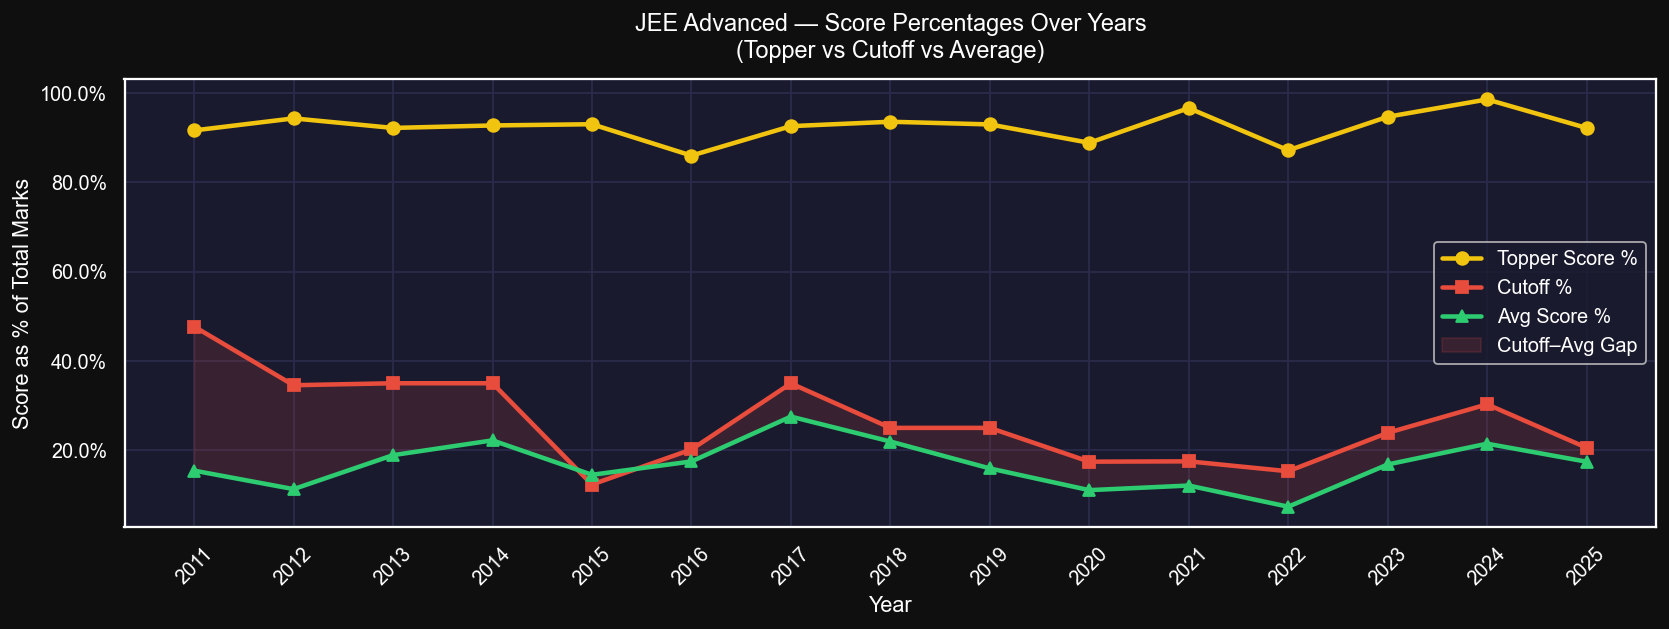

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df["Year"], df["Highest_pct"], marker="o", color="#f1c40f", linewidth=2.5, label="Topper Score %", markersize=7)
ax.plot(df["Year"], df["Cutoff_pct"], marker="s", color="#e74c3c", linewidth=2.5, label="Cutoff %", markersize=7)
ax.plot(df["Year"], df["Avg_pct"], marker="^", color="#2ecc71", linewidth=2.5, label="Avg Score %", markersize=7)

# Fill between cutoff and avg to show gap
ax.fill_between(df["Year"], df["Cutoff_pct"], df["Avg_pct"],
                alpha=0.15, color="#e74c3c", label="Cutoff–Avg Gap")

ax.set_title("JEE Advanced — Score Percentages Over Years\n(Topper vs Cutoff vs Average)", fontsize=13, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Score as % of Total Marks")
ax.set_xticks(df["Year"])
ax.set_xticklabels(df["Year"], rotation=45)
ax.legend(loc="center right")
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))

plt.tight_layout()
plt.savefig("02_score_percentages.png", bbox_inches="tight")
plt.show()

In [7]:
import plotly.graph_objects as go

fig = go.Figure()

# Topper line
fig.add_trace(go.Scatter(
    x=df["Year"],
    y=df["Highest_pct"],
    mode='lines+markers',
    name='Topper Score %',
    line=dict(color="#f1c40f", width=2.5),
    marker=dict(symbol='circle', size=7)
))

# Cutoff line
fig.add_trace(go.Scatter(
    x=df["Year"],
    y=df["Cutoff_pct"],
    mode='lines+markers',
    name='Cutoff %',
    line=dict(color="#e74c3c", width=2.5),
    marker=dict(symbol='square', size=7)
))

# Avg line
fig.add_trace(go.Scatter(
    x=df["Year"],
    y=df["Avg_pct"],
    mode='lines+markers',
    name='Avg Score %',
    line=dict(color="#2ecc71", width=2.5),
    marker=dict(symbol='triangle-up', size=7)
))

# Fill between Cutoff and Avg
fig.add_trace(go.Scatter(
    x=df["Year"],
    y=df["Avg_pct"],
    mode='lines',
    line=dict(width=0),
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=df["Year"],
    y=df["Cutoff_pct"],
    mode='lines',
    fill='tonexty',
    fillcolor='rgba(231, 76, 60, 0.15)',
    line=dict(width=0),
    name='Cutoff–Avg Gap'
))

# 🔥 DARK MODE LAYOUT
fig.update_layout(
    template="plotly_dark",   # main switch
    title="JEE Advanced — Score Percentages Over Years<br>(Topper vs Cutoff vs Average)",
    xaxis_title="Year",
    yaxis_title="Score as % of Total Marks",
    xaxis=dict(
        tickangle=45,
        rangeslider=dict(visible=False)  # ❌ remove slider
    ),
    yaxis=dict(ticksuffix="%"),
    legend=dict(x=1, y=0.5),
    plot_bgcolor="#1e1e1e",
    paper_bgcolor="#1e1e1e"
)

fig.write_html("02_score_percentages_dark.html")
fig.show()

BLOCK 4 — Subject-wise Average Marks Trend

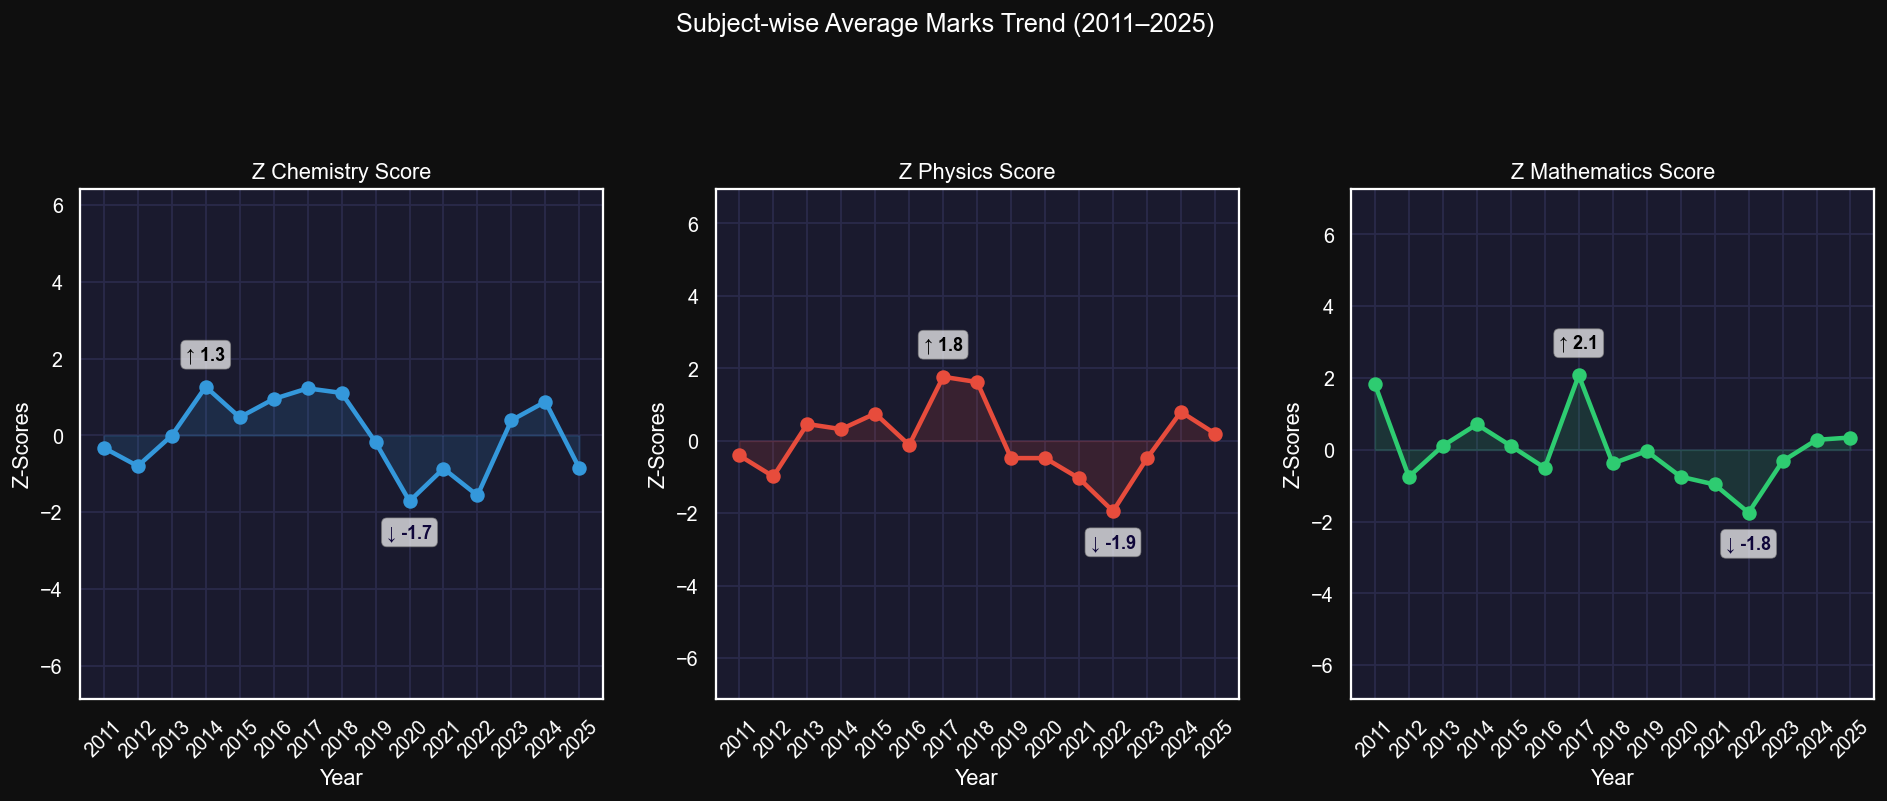

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Assuming 'df' is defined ---
# Example data for testing
# df = pd.DataFrame({"Year": range(2011, 2026), "Avg_Chem": [70+i for i in range(15)], 
#                    "Avg_Phy": [60+i for i in range(15)], "Avg_Math": [80+i for i in range(15)]})

# Z-score normalization (subject-wise)
df["Z_Chem"] = (df["Avg_Chem"] - df["Avg_Chem"].mean()) / df["Avg_Chem"].std()
df["Z_Math"] = (df["Avg_Math"] - df["Avg_Math"].mean()) / df["Avg_Math"].std()
df["Z_Phy"]  = (df["Avg_Phy"]  - df["Avg_Phy"].mean())  / df["Avg_Phy"].std()
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=False) # Increased figsize height
subjects = [("Z_Chem", "#3498db", "Chemistry"), ("Z_Phy", "#e74c3c", "Physics"), ("Z_Math", "#2ecc71", "Mathematics")]

for ax, (col, color, name) in zip(axes, subjects):
    ax.plot(df["Year"], df[col], marker="o", color=color, linewidth=2.5, markersize=7)
    ax.fill_between(df["Year"], df[col], alpha=0.15, color=color)
    
    # Annotate min and max
    max_idx = df[col].idxmax()
    min_idx = df[col].idxmin()
    
    # 1. Bolded and shifted annotations to prevent clipping
    # Increased xytext offset from (0, 10) to (0, 15) and (0, -15) to (0, -20)
    ax.annotate(f"↑ {df[col][max_idx]:.1f}", 
                xy=(df["Year"][max_idx], df[col][max_idx]), 
                xytext=(0, 15), 
                textcoords="offset points", 
                ha="center", 
                fontsize=10, 
                color="#000000",
                fontweight="bold", # BOLD
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.5, alpha=0.7)) # Optional: white box to make it readable
    
    ax.annotate(f"↓ {df[col][min_idx]:.1f}", 
                xy=(df["Year"][min_idx], df[col][min_idx]), 
                xytext=(0, -20), 
                textcoords="offset points", 
                ha="center", 
                fontsize=10, 
                color="#0f063a",
                fontweight="bold", # BOLD
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.5, alpha=0.7)) # Optional: white box

    ax.set_title(f"Z {name} Score", fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("Z-Scores")
    ax.set_xticks(df["Year"])
    ax.set_xticklabels(df["Year"], rotation=45)
    
    # 2. Add padding to y-axis to accommodate annotations
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min-5, y_max + 5)

plt.suptitle("Subject-wise Average Marks Trend (2011–2025)", fontsize=14, y=1.05) # Increased y
plt.tight_layout(pad=2.0) # Added padding to layout
plt.savefig("03_subject_avg_trend.png", bbox_inches="tight")
plt.show()


BLOCK 5 — Subject-wise Cutoff Trend

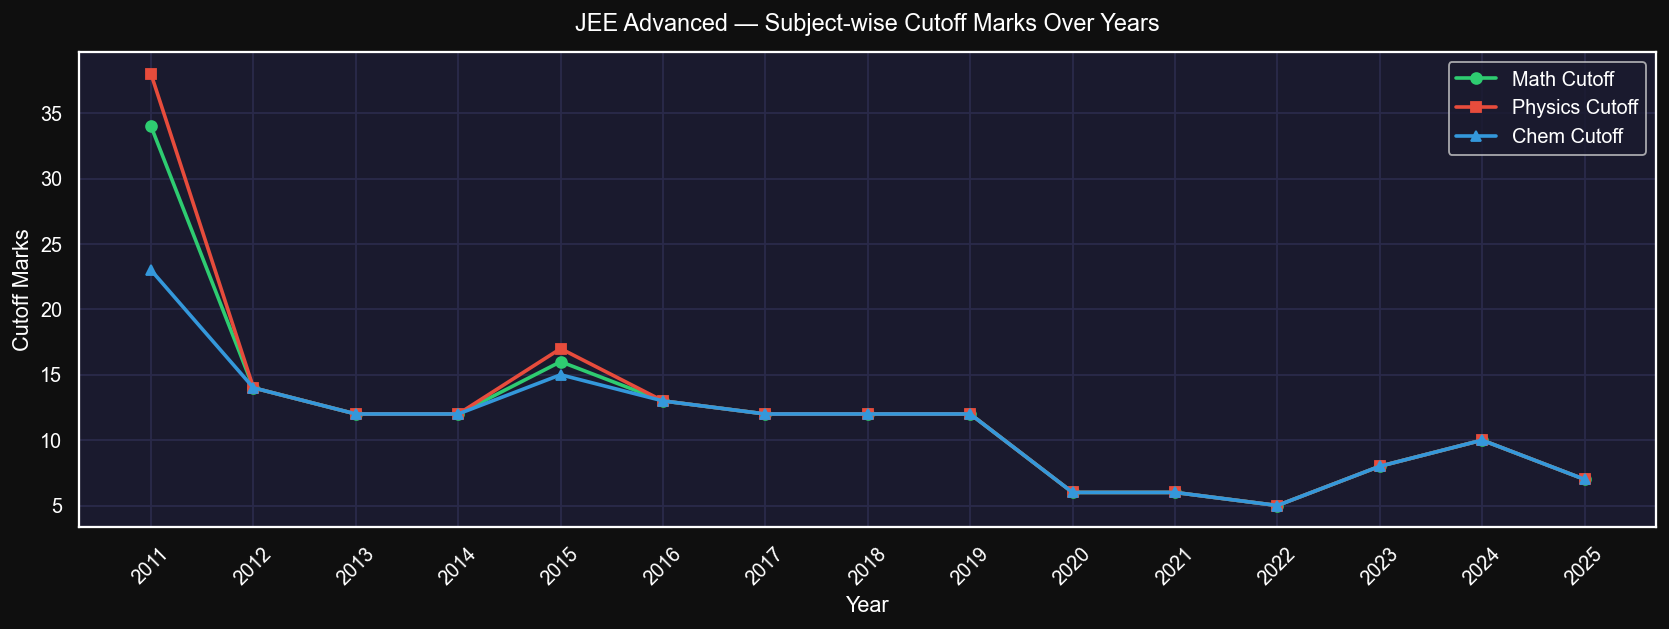

In [25]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df["Year"], df["Cutoff_Math"], marker="o", color="#2ecc71", linewidth=2, label="Math Cutoff", markersize=6)
ax.plot(df["Year"], df["Cutoff_Phys"], marker="s", color="#e74c3c", linewidth=2, label="Physics Cutoff", markersize=6)
ax.plot(df["Year"], df["Cutoff_Chem"], marker="^", color="#3498db", linewidth=2, label="Chem Cutoff", markersize=6)

ax.set_title("JEE Advanced — Subject-wise Cutoff Marks Over Years", fontsize=13, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Cutoff Marks")
ax.set_xticks(df["Year"])
ax.set_xticklabels(df["Year"], rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig("04_subjectwise_cutoff.png", bbox_inches="tight")
plt.show()

BLOCK 6 — Toughness Index (Composite)

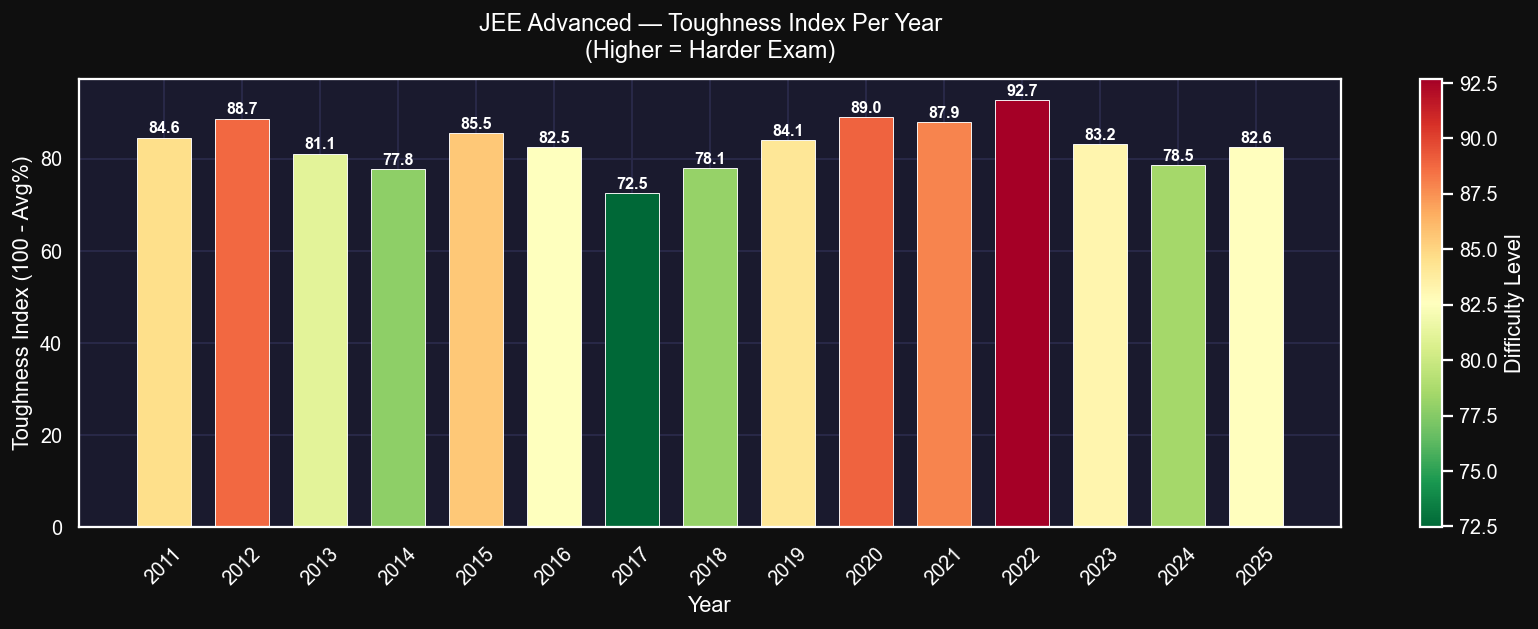

In [27]:
# Toughness = lower avg% + lower cutoff% = harder exam
# We invert avg_pct to get difficulty
df["Toughness_Index"] = 100 - df["Avg_pct"]

fig, ax = plt.subplots(figsize=(13, 5))

norm = plt.Normalize(df["Toughness_Index"].min(), df["Toughness_Index"].max())
colors = plt.cm.RdYlGn_r(norm(df["Toughness_Index"]))

bars = ax.bar(df["Year"], df["Toughness_Index"], color=colors, edgecolor="white", linewidth=0.5, width=0.7)

for bar, val in zip(bars, df["Toughness_Index"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}", ha="center", va="bottom", fontsize=9, color="white", fontweight="bold")

ax.set_title("JEE Advanced — Toughness Index Per Year\n(Higher = Harder Exam)", fontsize=13, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Toughness Index (100 - Avg%)")
ax.set_xticks(df["Year"])
ax.set_xticklabels(df["Year"], rotation=45)

sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Difficulty Level")

plt.tight_layout()
plt.savefig("05_toughness_index.png", bbox_inches="tight")
plt.show()

BLOCK 7 — Topper vs Cutoff Gap (Elite vs Minimum)

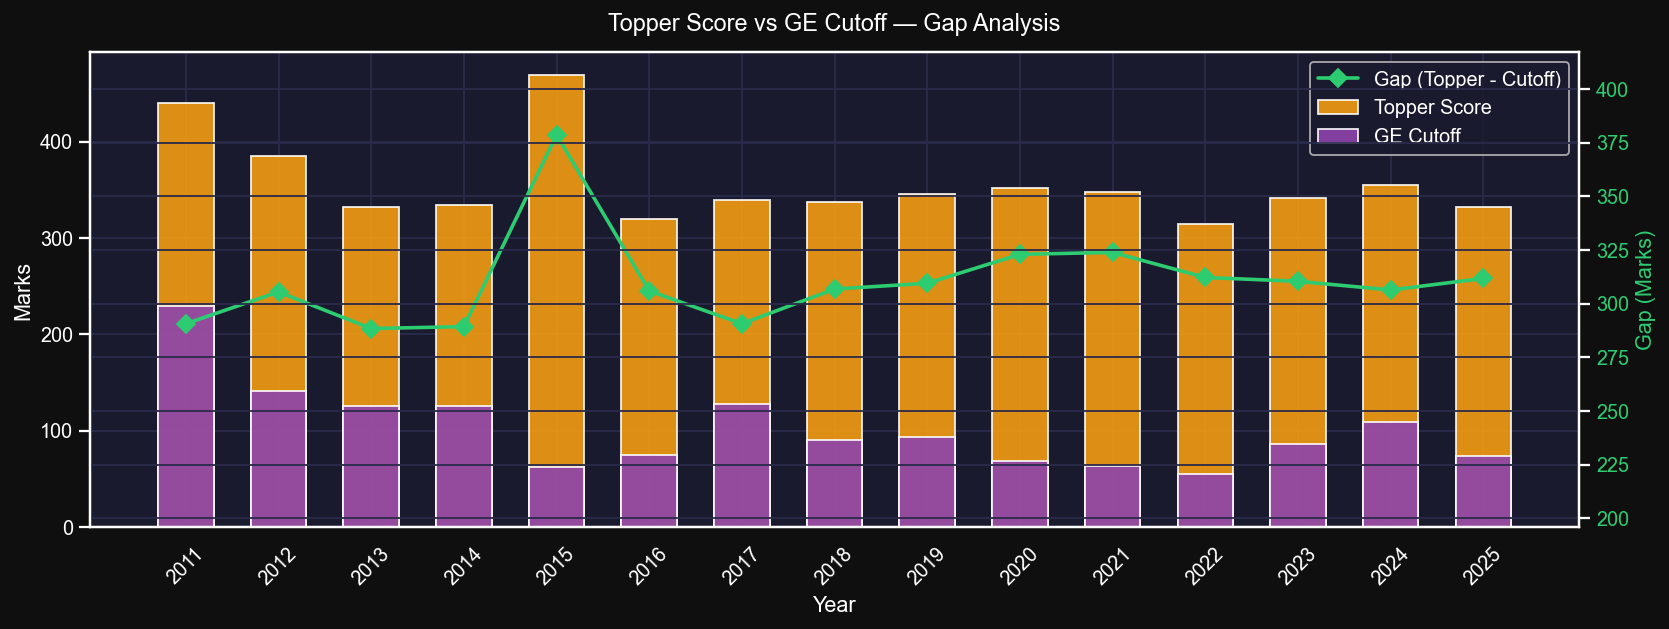

In [30]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(df["Year"], df["Highest_Score"], color="#f39c12", label="Topper Score", width=0.6, alpha=0.9)
ax.bar(df["Year"], df["GE_Aggregate_Cutoff"], color="#8e44ad", label="GE Cutoff", width=0.6, alpha=0.9)

ax.plot(df["Year"], df["Topper_vs_Cutoff_Gap"], color="#2ecc71", marker="D",
        linewidth=2, markersize=7, label="Gap (Topper - Cutoff)", zorder=5)

ax2 = ax.twinx()
ax2.plot(df["Year"], df["Topper_vs_Cutoff_Gap"], color="#2ecc71", linewidth=0, markersize=0)
ax2.set_ylabel("Gap (Marks)", color="#2ecc71")
ax2.tick_params(axis='y', labelcolor='#2ecc71')

ax.set_title("Topper Score vs GE Cutoff — Gap Analysis", fontsize=13, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Marks")
ax.set_xticks(df["Year"])
ax.set_xticklabels(df["Year"], rotation=45)
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig("06_topper_vs_cutoff.png", bbox_inches="tight")
plt.show()

BLOCK 8 — Bonus Marks Impact

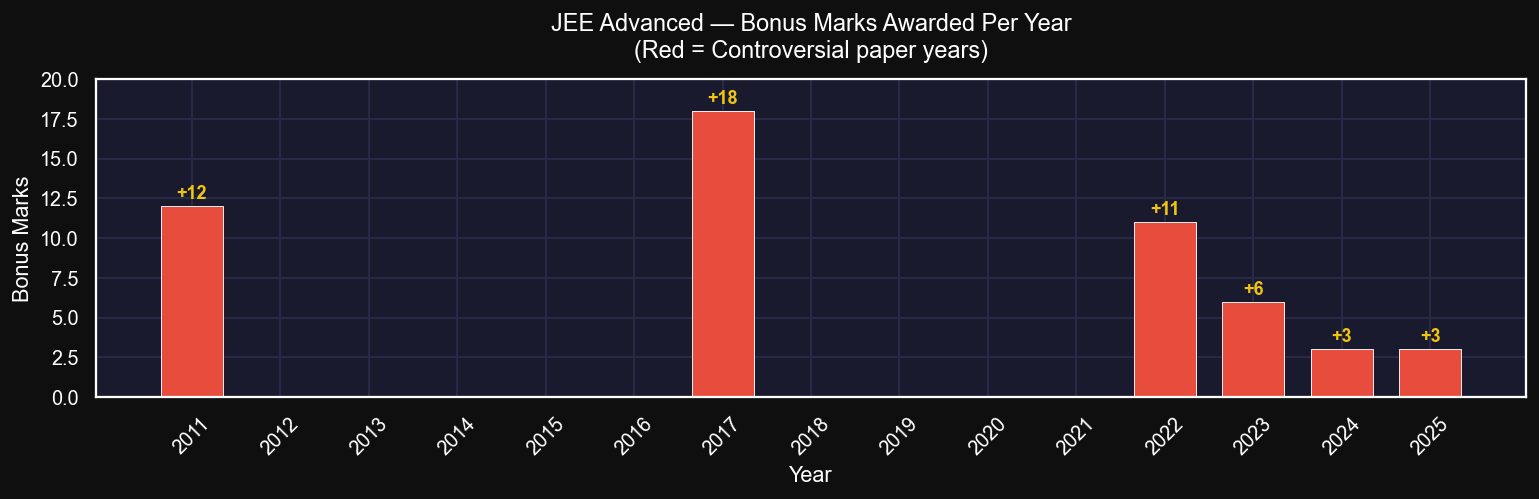

In [31]:
bonus_years = df[df["Bonus_Marks"] > 0]

fig, ax = plt.subplots(figsize=(12, 4))
bar_colors = ["#e74c3c" if b > 0 else "#2c3e50" for b in df["Bonus_Marks"]]
bars = ax.bar(df["Year"], df["Bonus_Marks"], color=bar_colors, edgecolor="white", linewidth=0.5, width=0.7)

for bar, val in zip(bars, df["Bonus_Marks"]):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f"+{val}", ha="center", va="bottom", fontsize=10, color="#f1c40f", fontweight="bold")

ax.set_title("JEE Advanced — Bonus Marks Awarded Per Year\n(Red = Controversial paper years)", fontsize=13, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Bonus Marks")
ax.set_xticks(df["Year"])
ax.set_xticklabels(df["Year"], rotation=45)

ax.set_ylim(0,20)
plt.tight_layout()
plt.savefig("07_bonus_marks.png", bbox_inches="tight")
plt.show()

BLOCK 10 — Summary Stats Print (for documentation)

In [33]:
print("=" * 55)
print("       JEE ADVANCED EXAM LEVEL — KEY INSIGHTS")
print("=" * 55)
print(f"Years Covered         : {df['Year'].min()} – {df['Year'].max()}")
print(f"Hardest Year (Avg%)   : {df.loc[df['Avg_pct'].idxmin(), 'Year']} ({df['Avg_pct'].min():.2f}%)")
print(f"Easiest Year (Avg%)   : {df.loc[df['Avg_pct'].idxmax(), 'Year']} ({df['Avg_pct'].max():.2f}%)")
print(f"Highest Ever Score    : {df['Highest_Score'].max()} ({df.loc[df['Highest_Score'].idxmax(), 'Year']})")
print(f"Lowest Cutoff %       : {df['Cutoff_pct'].min():.2f}% ({df.loc[df['Cutoff_pct'].idxmin(), 'Year']})")
print(f"Highest Cutoff %      : {df['Cutoff_pct'].max():.2f}% ({df.loc[df['Cutoff_pct'].idxmax(), 'Year']})")
print(f"Bonus Marks Years     : {list(df[df['Bonus_Marks']>0]['Year'])}")
print(f"Avg Toughness Index   : {df['Toughness_Index'].mean():.2f}")
print("=" * 55)

       JEE ADVANCED EXAM LEVEL — KEY INSIGHTS
Years Covered         : 2011 – 2025
Hardest Year (Avg%)   : 2022 (7.33%)
Easiest Year (Avg%)   : 2017 (27.53%)
Highest Ever Score    : 469 (2015)
Lowest Cutoff %       : 12.30% (2015)
Highest Cutoff %      : 47.71% (2011)
Bonus Marks Years     : [2011, 2017, 2022, 2023, 2024, 2025]
Avg Toughness Index   : 83.25
